# **Data Analysis using Python Pandas Library**

## Python Skill Objectives
- load csv data from a file using Numpy
- load csv data from a file using Pandas library.
- know how to get info on the data in a dataframe, access data in DataFrames.
- create plots of data in DataFrames.
- save figures to file.


## Geoscience Objectives
- Understand how to read USGS discharge data

We will be looking at data on river discharge of the Upper Colorado River. 

Tabular data like this with a combination of dates, name and data quality strings, and numbers are best handled by spreadsheets where entries such as dates and times are in some useful format. In Python, the Python Data Analysis Library (a.k.a. Pandas) is really useful for this purpose.

I use one discharge data file downloaded for the USGS station at Kremmling, CO, for the Upper Colorado. 

In this notebook we will use partially cleaned up files, because the headers in either the USGS files is unique for each station, making it difficult to deal with it in an automated way. To prepare the file I cut of the header in a text-editor and saved it as a *.csv file. 

#### Note: Be sure you're set up in the CSDMS kernel (top right optional tab).

# Review 
## Reading file data into a numpy array: loadtxt 

If our goal is to read the contents of a text file into a numpy array, numpy provides functions that makes this a bit easier. Let's remember: 
- `loadtxt()` : simple and effective when you have all numbers plus some comments or header lines <br>


# Note, we're going to do things a little differently today. This is going to be a **Demo notebook**. Then you're going to have a **Pandas Worksheet** that we're going to work on as well.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Let's see what version we're using...
print(f"Pandas version: {pd.__version__}")

Pandas version: 2.3.2


# ~~~ **Lecture 1** ~~~
which goes with Ex 1 from the worksheet

# 1. Introduction to Pandas

## Pandas = Python Data Analysis Library
#### When to use what:
- **NumPy**: numerical calculations, arrays of numbers, mathematical operations
- **Pandas**: Tabular data (like spreadsheets), mixed data types, data with labels/headers
#### A **DataFrame** is Pandas' main data structure:
- a 2D table with rows and columns
- each column can have a different data type
- columns have names, rows have indices
- think of it like an Excel spreadsheet in Python!
- it allows for efficient searching for particular rows and columns
- has built it functionality to analyze basic statistical properities of the data

# 2. Loading Data

## Let's load a csv-file into a Pandas DataFrame

Instead of using `np.loadtxt(..)`, we can use
```python
pd.read_csv()
```
No need to tell it the delimiter!

In [3]:
df = pd.read_csv('USGS09058000_discharge_NoHead_20112021.csv')

What does the data look like?

In [3]:
df

,agency_cd,site_no,datetime,discharge-cuft
0,USGS,9058000,1/1/2011,311.0
1,USGS,9058000,1/2/2011,348.0
2,USGS,9058000,1/3/2011,387.0
3,USGS,9058000,1/4/2011,378.0
4,USGS,9058000,1/5/2011,381.0
...,...,...,...,...
3907,USGS,9058000,9/12/2021,1110.0
3908,USGS,9058000,9/13/2021,1060.0
3909,USGS,9058000,9/14/2021,1070.0
3910,USGS,9058000,9/15/2021,1010.0


### What just happened?
- `pd.read_csv()` read the CSV file and created a DataFrame
- the DataFrame automatically used the first row as column headers
- Pandas guessed the data types for each column
#### Note: if you get an error, check:
- Is the file in the same folder as your notebook?
- Did you spell the filename correctly?
- Does the file exist?

You could also do the following, but as you can tell...it's not a nice...

In [4]:
print(df)

     agency_cd  site_no   datetime  discharge-cuft
0         USGS  9058000   1/1/2011           311.0
1         USGS  9058000   1/2/2011           348.0
2         USGS  9058000   1/3/2011           387.0
3         USGS  9058000   1/4/2011           378.0
4         USGS  9058000   1/5/2011           381.0
...        ...      ...        ...             ...
3907      USGS  9058000  9/12/2021          1110.0
3908      USGS  9058000  9/13/2021          1060.0
3909      USGS  9058000  9/14/2021          1070.0
3910      USGS  9058000  9/15/2021          1010.0
3911      USGS  9058000  9/16/2021           975.0

[3912 rows x 4 columns]


# 3. Exploring DataFrames

When we use `pd.readcsv()` a DataFrame *object* this means we will use *methods* to parse through the DataFrame.

Here are some essential exploration methods:
|Method or Python Function| Use|
|:--|:--|
|`df.head()`|to see the headers and the *first* few rows|
|`df.head(10)`|to see the headers and the *first* 10 rows|
|`df.tail()`|to see the headers and the *last* few rows|
|`df.tail(10)`|to see the headers and the *last* 10 rows|
|`df.info()`|to see general information about the DataFrame|

`df.info()` tells us:
- number of rows (entries)
- number of columns
- column names
- how many non-null values (missing data?)
- data type of each column
- memory usage

|Method or Python Function| Use|
|:--|:--|
|`print(type(df))`<br> `print(df.__class__)` <br>|to see the type of the object data|
|`df.dtypes`|to see the data type for each column|

`df.types` will let you see the data types. <br>
Common data types:
- `int64`: integers
- `float64`: floats
- `object`: strings or mixed types
- `datetime64`: dates and times

|Method or Python Function| Use|
|:--|:--|
|`df.shape`|to see the shape (rows, columns)|
|`len(df)`|to see the number of rows|

# 4. Selecting Data & Renaming Columns

To see our current column names, we can do:

In [4]:
print(df.columns)

Index(['agency_cd', 'site_no', 'datetime', 'discharge-cuft'], dtype='object')


These names are okay, but we can make them clearer! Before we change them, we need to know **how to select them**.
### Selecting a Single Column
Let's start with the discharge column. We can select it but using it's name. When we run the below code, we get a **Panda Series** returned (a single column):

In [5]:
df['discharge-cuft']

0        311.0
1        348.0
2        387.0
3        378.0
4        381.0
         ...  
3907    1110.0
3908    1060.0
3909    1070.0
3910    1010.0
3911     975.0
Name: discharge-cuft, Length: 3912, dtype: float64

### Selecting Multiple Columns
We can use a LIST of column names inside the brackets to select multiple columns

In [6]:
df[['datetime', 'discharge-cuft']]

,datetime,discharge-cuft
0,1/1/2011,311.0
1,1/2/2011,348.0
2,1/3/2011,387.0
3,1/4/2011,378.0
4,1/5/2011,381.0
...,...,...
3907,9/12/2021,1110.0
3908,9/13/2021,1060.0
3909,9/14/2021,1070.0
3910,9/15/2021,1010.0


#### **Common Mistake**: forgetting the double brackets!
- `df['column']` --> single column (Series)
- `df[['column']]` --> single column (DataFrame)
- `df[['col1', 'col2']]` --> multiple columns (DataFrame)

## Renaming Columns
Now that we know how to call columns, let's give them better names!

- create a list of new names that are in the same order as the current columns.
- assign the new names
- check that it worked

In [7]:
new_names = ['Agency', 'SiteNo', 'DateTime', 'Discharge_cfs']
df.columns = new_names
df.head()

,Agency,SiteNo,DateTime,Discharge_cfs
0,USGS,9058000,1/1/2011,311.0
1,USGS,9058000,1/2/2011,348.0
2,USGS,9058000,1/3/2011,387.0
3,USGS,9058000,1/4/2011,378.0
4,USGS,9058000,1/5/2011,381.0


#### Why rename?
- easier to type (no special characters like `-`)
- more descriptive
- consistent sytle (we like underscores for multi-word names)

Now we can select columns with the new names:

In [8]:
df[['Discharge_cfs']].head()

,Discharge_cfs
0,311.0
1,348.0
2,387.0
3,378.0
4,381.0


# 5. Adding and Modifying Columns

## Adding a New Column with a Calculation
Let's convert discharge from cubic feet per second (cfs) to cubic meters per second (m$^3$/s)<br>
**Conversion factor**: 1cfs = 0.028316847 m$^3$/s

We can do math on columns, just like we would on arrays:

In [9]:
# create a new column by doing math on an existing column
df['Discharge_m3s'] = df['Discharge_cfs']*0.028316847
# check that it worked
df.head()

,Agency,SiteNo,DateTime,Discharge_cfs,Discharge_m3s
0,USGS,9058000,1/1/2011,311.0,8.806539
1,USGS,9058000,1/2/2011,348.0,9.854263
2,USGS,9058000,1/3/2011,387.0,10.958620
3,USGS,9058000,1/4/2011,378.0,10.703768
4,USGS,9058000,1/5/2011,381.0,10.788719


### What just happened?
- Pandas multiplied EVERY value in `Discharge_cfs` by the conversion factor
- it created a new column with the results
- This is called **vectorization**, no loops needed!

We could also modify an existing column:
```python
df['Discharge_cfs'] = df['Discharge_cfs']*0.028316847
```
BUT this will overwrite the original data. In this case we don't want to do that because our column has the unit in its name...so now we no longer have cubic feet per second stored in a column with 'cfs'...

## You can add any column!
Let's add a column of text (same value for all rows)

In [10]:
df['Station_Name'] = 'Kremmling'
df.head()

,Agency,SiteNo,DateTime,Discharge_cfs,Discharge_m3s,Station_Name
0,USGS,9058000,1/1/2011,311.0,8.806539,Kremmling
1,USGS,9058000,1/2/2011,348.0,9.854263,Kremmling
2,USGS,9058000,1/3/2011,387.0,10.958620,Kremmling
3,USGS,9058000,1/4/2011,378.0,10.703768,Kremmling
4,USGS,9058000,1/5/2011,381.0,10.788719,Kremmling


## Or remove any column!
But we don't want that so let's get rid of it.

In [11]:
df = df.drop('Station_Name', axis=1) # columns are axis=1
df.head()

,Agency,SiteNo,DateTime,Discharge_cfs,Discharge_m3s
0,USGS,9058000,1/1/2011,311.0,8.806539
1,USGS,9058000,1/2/2011,348.0,9.854263
2,USGS,9058000,1/3/2011,387.0,10.958620
3,USGS,9058000,1/4/2011,378.0,10.703768
4,USGS,9058000,1/5/2011,381.0,10.788719


# 6. Basic Statistics

Pandas makes it easy to calculate statistics on your data.

## The Essential Statistics Methods:
|method|what it does|
|--:|:--|
|`df['column'].sum()`|adds all values|
|`df['column'].mean()`|calculates average|
|`df['column'].median()`|finds middle value|
|`df['column'].min()`<br> `df['column'].max()`|finds smallest/largest value|
|`df['column'].idxmin()`<br> `df['column'].idxmax()`|finds index of the min/max value|
|`df['column'].std()`|standard deviation|


In [12]:
print(f"Mean discharge: {df['Discharge_cfs'].mean():.2f} cfs")
print(f"Max discharge: {df['Discharge_cfs'].max():.2f} cfs")
print(f"Min discharge: {df['Discharge_cfs'].min():.2f} cfs")
print(f"Standard deviation: {df['Discharge_cfs'].std():.2f} cfs")
print(f"Total discharge: {df['Discharge_cfs'].sum():.2f} cfs")

Mean discharge: 1146.70 cfs
Max discharge: 9480.00 cfs
Min discharge: 266.00 cfs
Standard deviation: 1312.05 cfs
Total discharge: 4479001.00 cfs


We can get all the statistics at once using `.describe()`

In [13]:
df['Discharge_cfs'].describe()

count    3906.000000
mean     1146.697645
std      1312.046712
min       266.000000
25%       471.250000
50%       715.000000
75%      1180.000000
max      9480.000000
Name: Discharge_cfs, dtype: float64

<div class="alert alert-warning">

# Connecting to our Pandas Worksheet
### With JUST the above lecture material (and your previous knowledge/skills), you can complete Exercise 1 in your PandasWorksheet.

# ~~~ **Lecture 2** ~~~
which goes with Ex 2-6 from worksheet

# Quick Review
Let's reload our data and apply what we learned last time:

In [14]:
# load data
df = pd.read_csv('USGS09058000_discharge_NoHead_20112021.csv')

# rename columns
df.columns = ['Agency', 'SiteNo', 'DateTime', 'Discharge_cfs']

# Add m3/s column
# 1 cu ft = 0.028316847 cu m
df['Discharge_m3s'] = df["Discharge_cfs"]*0.028316847

# Check our work
df.head()

,Agency,SiteNo,DateTime,Discharge_cfs,Discharge_m3s
0,USGS,9058000,1/1/2011,311.0,8.806539
1,USGS,9058000,1/2/2011,348.0,9.854263
2,USGS,9058000,1/3/2011,387.0,10.958620
3,USGS,9058000,1/4/2011,378.0,10.703768
4,USGS,9058000,1/5/2011,381.0,10.788719


#### Answer

In [15]:
# load data
df = pd.read_csv('USGS09058000_discharge_NoHead_20112021.csv')

# rename columns
df.columns = ['Agency', 'SiteNo', 'DateTime', 'Discharge_cfs']

# Add m3/s column
df['Discharge_m3s'] = df['Discharge_cfs'] * 0.028316847

# Check our work
df.head()

,Agency,SiteNo,DateTime,Discharge_cfs,Discharge_m3s
0,USGS,9058000,1/1/2011,311.0,8.806539
1,USGS,9058000,1/2/2011,348.0,9.854263
2,USGS,9058000,1/3/2011,387.0,10.958620
3,USGS,9058000,1/4/2011,378.0,10.703768
4,USGS,9058000,1/5/2011,381.0,10.788719


# **Questions from Exercise 1?**

# 7. Working with DateTime

Working with dates can be weird.

## The Problem with dates as strings
What type is our DateTime column?

In [16]:
print(df['DateTime'].dtype)

object


It's an `object` (string). This means:
- we can't extract the year, month, or day
- we can't do date math
- we can't plot properly on the time axis

Overall, this is **very inconvenient**. The good news is there is a fix!

## Converting to DateTime
We can convert the string of our date to a datetime object using the method `to_datetime()`:

In [17]:
df['DateTime'] = pd.to_datetime(df['DateTime'])
print(df['DateTime'].dtype)

datetime64[ns]


Now it's a `datetime64`!

This conversion might take a moment, so be patient...

Let's now look at the header:

In [18]:
df.head()

,Agency,SiteNo,DateTime,Discharge_cfs,Discharge_m3s
0,USGS,9058000,2011-01-01,311.0,8.806539
1,USGS,9058000,2011-01-02,348.0,9.854263
2,USGS,9058000,2011-01-03,387.0,10.958620
3,USGS,9058000,2011-01-04,378.0,10.703768
4,USGS,9058000,2011-01-05,381.0,10.788719


While this looks similar, the format is slightly different. This means we can do datetime operations!

## Extracting Parts of the Date
We can extract the year..

In [19]:
df['Year'] = df['DateTime'].dt.year
df.head()

,Agency,SiteNo,DateTime,Discharge_cfs,Discharge_m3s,Year
0,USGS,9058000,2011-01-01,311.0,8.806539,2011
1,USGS,9058000,2011-01-02,348.0,9.854263,2011
2,USGS,9058000,2011-01-03,387.0,10.958620,2011
3,USGS,9058000,2011-01-04,378.0,10.703768,2011
4,USGS,9058000,2011-01-05,381.0,10.788719,2011


...the month...

In [20]:
df['Month'] = df['DateTime'].dt.month
df.head()

,Agency,SiteNo,DateTime,Discharge_cfs,Discharge_m3s,Year,Month
0,USGS,9058000,2011-01-01,311.0,8.806539,2011,1
1,USGS,9058000,2011-01-02,348.0,9.854263,2011,1
2,USGS,9058000,2011-01-03,387.0,10.958620,2011,1
3,USGS,9058000,2011-01-04,378.0,10.703768,2011,1
4,USGS,9058000,2011-01-05,381.0,10.788719,2011,1


...the day...

In [21]:
df['Day'] = df['DateTime'].dt.day
df.head()

,Agency,SiteNo,DateTime,Discharge_cfs,Discharge_m3s,Year,Month,Day
0,USGS,9058000,2011-01-01,311.0,8.806539,2011,1,1
1,USGS,9058000,2011-01-02,348.0,9.854263,2011,1,2
2,USGS,9058000,2011-01-03,387.0,10.958620,2011,1,3
3,USGS,9058000,2011-01-04,378.0,10.703768,2011,1,4
4,USGS,9058000,2011-01-05,381.0,10.788719,2011,1,5


...even the day of the year OR the day of the week (0=Monday, 6=Sunday)!

In [22]:
df['DayOfYear'] = df['DateTime'].dt.dayofyear
df['DayOfWeek'] = df['DateTime'].dt.dayofweek
df.head()

,Agency,SiteNo,DateTime,Discharge_cfs,Discharge_m3s,Year,Month,Day,DayOfYear,DayOfWeek
0,USGS,9058000,2011-01-01,311.0,8.806539,2011,1,1,1,5
1,USGS,9058000,2011-01-02,348.0,9.854263,2011,1,2,2,6
2,USGS,9058000,2011-01-03,387.0,10.958620,2011,1,3,3,0
3,USGS,9058000,2011-01-04,378.0,10.703768,2011,1,4,4,1
4,USGS,9058000,2011-01-05,381.0,10.788719,2011,1,5,5,2


## **Why is this useful?**
We can now filter our data by year, month, day, whatever!

In [23]:
df_2020 = df[df['Year'] == 2020]

print(f"Data from 2020: {len(df_2020)} days")
df_2020.head()

Data from 2020: 366 days


,Agency,SiteNo,DateTime,Discharge_cfs,Discharge_m3s,Year,Month,Day,DayOfYear,DayOfWeek
3287,USGS,9058000,2020-01-01,396.0,11.213471,2020,1,1,1,2
3288,USGS,9058000,2020-01-02,403.0,11.411689,2020,1,2,2,3
3289,USGS,9058000,2020-01-03,402.0,11.383372,2020,1,3,3,4
3290,USGS,9058000,2020-01-04,396.0,11.213471,2020,1,4,4,5
3291,USGS,9058000,2020-01-05,399.0,11.298422,2020,1,5,5,6


### **Key Pattern:** `df['DateTime'].dt.property`

# 8. Indexing: `loc` vs `iloc`

There are two main ways to select data in Pandas. Let's understand them both.

## `iloc` - Integer Location (position-based)
Think of `iloc` as "integer location" because it sues position numbers like list indexing.

**We can get the first row (position 0) of our DataFrame like this:**

In [24]:
df.iloc[0]

Agency                          USGS
SiteNo                       9058000
DateTime         2011-01-01 00:00:00
Discharge_cfs                  311.0
Discharge_m3s               8.806539
Year                            2011
Month                              1
Day                                1
DayOfYear                          1
DayOfWeek                          5
Name: 0, dtype: object

**or the first 5 rows like...**

In [25]:
df.iloc[0:5]

,Agency,SiteNo,DateTime,Discharge_cfs,Discharge_m3s,Year,Month,Day,DayOfYear,DayOfWeek
0,USGS,9058000,2011-01-01,311.0,8.806539,2011,1,1,1,5
1,USGS,9058000,2011-01-02,348.0,9.854263,2011,1,2,2,6
2,USGS,9058000,2011-01-03,387.0,10.958620,2011,1,3,3,0
3,USGS,9058000,2011-01-04,378.0,10.703768,2011,1,4,4,1
4,USGS,9058000,2011-01-05,381.0,10.788719,2011,1,5,5,2


**or a specific cell (row 0, column 3) like:**

In [26]:
df.iloc[0, 3]

np.float64(311.0)

**or the last row like...**

In [27]:
df.iloc[-1]

Agency                          USGS
SiteNo                       9058000
DateTime         2021-09-16 00:00:00
Discharge_cfs                  975.0
Discharge_m3s              27.608926
Year                            2021
Month                              9
Day                               16
DayOfYear                        259
DayOfWeek                          3
Name: 3911, dtype: object

**or rows 10-15, columns 2-4 like...**

In [28]:
df.iloc[10:15, 1:4]

,SiteNo,DateTime,Discharge_cfs
10,9058000,2011-01-11,334.0
11,9058000,2011-01-12,369.0
12,9058000,2011-01-13,376.0
13,9058000,2011-01-14,394.0
14,9058000,2011-01-15,387.0


### Think of `iloc` as array/list indexing:
- uses numbers only
- starts at 0
- slicing works like python lists

## `loc` - Label Location (name-based)
Think of `loc` as "location by label" - it uses row labels and column names

**We can get the value stored at the row with index label 0 and the column named 'Discharge_cfs' like this**:

In [29]:
df.loc[0, 'Discharge_cfs']

np.float64(311.0)

**or the specific rows and columns by name**

In [30]:
df.loc[0:5, ['DateTime', 'Discharge_cfs']]

,DateTime,Discharge_cfs
0,2011-01-01,311.0
1,2011-01-02,348.0
2,2011-01-03,387.0
3,2011-01-04,378.0
4,2011-01-05,381.0
5,2011-01-06,377.0


**or all rows, but specific columns**

In [31]:
df.loc[:, ['DateTime', 'Discharge_cfs', 'Year']]

,DateTime,Discharge_cfs,Year
0,2011-01-01,311.0,2011
1,2011-01-02,348.0,2011
2,2011-01-03,387.0,2011
3,2011-01-04,378.0,2011
4,2011-01-05,381.0,2011
...,...,...,...
3907,2021-09-12,1110.0,2021
3908,2021-09-13,1060.0,2021
3909,2021-09-14,1070.0,2021
3910,2021-09-15,1010.0,2021


### **When to Use Which?**
#### Use `iloc` when:
- you want the first/last N rows
- you're working with positions (row 5, column 3)
- you're slicing by position

#### Use `loc` when:
- you're filtering by condition (we'll see this next!)
- you want specific named columns
- you're using the index labels

## **Help me out.**
What is the difference between these two?
```python
print(df.iloc[0, 3])
print(df.loc[0, 'Discharge_cfs'])

#### Answer

In [32]:
print(df.iloc[0, 3])

311.0


In [33]:
print(df.loc[0, 'Discharge_cfs'])

311.0


# 9. Boolean Indexing (Filtering)

This is one of the msot powerful Pandas features!

## Step 1 : Create a Boolean Array
We'll start with trying to figure out which days had discharge over 2000 cfs.
#### What is a boolean?

In [34]:
high_flow = df['Discharge_cfs'] > 2000 # creates the boolean
print(high_flow.head(10)) # print out the first 20 values

0    False
1    False
2    False
3    False
4    False
5    False
6    False
7    False
8    False
9    False
Name: Discharge_cfs, dtype: bool


**then we can easily find out how many `True` values there are:**

In [35]:
print(f"High flow days: {high_flow.sum()}")

High flow days: 445


## Step 2: Use the Boolean Array to Filter
Now we want to grab only the rows where `high_flow` is `True`

In [36]:
df_high = df[high_flow]
print(f"Filtered to {len(df_high)} high flow days")
df_high.head()

Filtered to 445 high flow days


,Agency,SiteNo,DateTime,Discharge_cfs,Discharge_m3s,Year,Month,Day,DayOfYear,DayOfWeek
108,USGS,9058000,2011-04-19,2020.0,57.200031,2011,4,19,109,1
110,USGS,9058000,2011-04-21,2070.0,58.615873,2011,4,21,111,3
111,USGS,9058000,2011-04-22,2300.0,65.128748,2011,4,22,112,4
112,USGS,9058000,2011-04-23,2140.0,60.598053,2011,4,23,113,5
119,USGS,9058000,2011-04-30,2200.0,62.297063,2011,4,30,120,5


## Step 3: Do it all in one line! 
Now that we know all the steps, here's how you do it one line:

In [37]:
df_high = df[df['Discharge_cfs'] > 2000]
df_high.head()

,Agency,SiteNo,DateTime,Discharge_cfs,Discharge_m3s,Year,Month,Day,DayOfYear,DayOfWeek
108,USGS,9058000,2011-04-19,2020.0,57.200031,2011,4,19,109,1
110,USGS,9058000,2011-04-21,2070.0,58.615873,2011,4,21,111,3
111,USGS,9058000,2011-04-22,2300.0,65.128748,2011,4,22,112,4
112,USGS,9058000,2011-04-23,2140.0,60.598053,2011,4,23,113,5
119,USGS,9058000,2011-04-30,2200.0,62.297063,2011,4,30,120,5


You'd read that first line of code as: **"Give me the rows of `df` where the `Discharge_cfs` column is greater than 2000"**

## More Filtering Examples!
We can do all sorts of different filtering using Pandas. Here are just a few examples:

#### **Filtering for a specific year**

In [38]:
df_2015 = df[df['Year'] == 2015]
print(f"Days in 2015: {len(df_2015)}")
df_2015.head()

Days in 2015: 365


,Agency,SiteNo,DateTime,Discharge_cfs,Discharge_m3s,Year,Month,Day,DayOfYear,DayOfWeek
1461,USGS,9058000,2015-01-01,519.0,14.696444,2015,1,1,1,3
1462,USGS,9058000,2015-01-02,520.0,14.724760,2015,1,2,2,4
1463,USGS,9058000,2015-01-03,520.0,14.724760,2015,1,3,3,5
1464,USGS,9058000,2015-01-04,520.0,14.724760,2015,1,4,4,6
1465,USGS,9058000,2015-01-05,520.0,14.724760,2015,1,5,5,0


#### **Filtering for low flow days**

In [39]:
df_low = df[df['Discharge_cfs'] < 500]
print(f"Low flow days: {len(df_low)}")
df_low.head()

Low flow days: 1151


,Agency,SiteNo,DateTime,Discharge_cfs,Discharge_m3s,Year,Month,Day,DayOfYear,DayOfWeek
0,USGS,9058000,2011-01-01,311.0,8.806539,2011,1,1,1,5
1,USGS,9058000,2011-01-02,348.0,9.854263,2011,1,2,2,6
2,USGS,9058000,2011-01-03,387.0,10.958620,2011,1,3,3,0
3,USGS,9058000,2011-01-04,378.0,10.703768,2011,1,4,4,1
4,USGS,9058000,2011-01-05,381.0,10.788719,2011,1,5,5,2


## Combining Multiple Conditions
When using Pandas, you can use `&` for AND, `|` for OR. <br>
**Important**: Use parentheses around each condition!

#### **Filtering high flow days in 2020**

In [40]:
df_filtered = df[(df['Year'] == 2020) & (df['Discharge_cfs'] > 2000)]
print(f"High flow days in 2020: {len(df_filtered)}")
df_filtered.head()

High flow days in 2020: 19


,Agency,SiteNo,DateTime,Discharge_cfs,Discharge_m3s,Year,Month,Day,DayOfYear,DayOfWeek
3421,USGS,9058000,2020-05-14,2140.0,60.598053,2020,5,14,135,3
3422,USGS,9058000,2020-05-15,2150.0,60.881221,2020,5,15,136,4
3423,USGS,9058000,2020-05-16,2140.0,60.598053,2020,5,16,137,5
3424,USGS,9058000,2020-05-17,2080.0,58.899042,2020,5,17,138,6
3425,USGS,9058000,2020-05-18,2070.0,58.615873,2020,5,18,139,0


#### **Filtering days from 2015 OR 2016**

In [41]:
df_two_years = df[(df['Year'] == 2015) | (df['Year'] == 2016)]
print(f"Days from 2015 or 2016: {len(df_two_years)}")

Days from 2015 or 2016: 731


#### Common Mistake: Forgetting the parentheses!

#### **Key Pattern**: `df[df['column'] > value]`

# 10. Looping through Rows with `.iterrows()`

Sometimes you need to look at each row individually and make decisions based on multiple columns. That's where `.iterrows()` comes in.

- `.iterrows()` lets you loop through a DataFrame **one row at a time**. Each iteration gives you:
    - the **index** (row number)
    - the **row** istelf (containing all column values)<br>
Basic Syntax:
```python
for index, row in df.iterrows():
    # access column values using row['column_name']
    value = row['column_name']
```
**Let's see it in action by looking at the first 5 rows of our DataFrame:**

In [42]:
print("First 5 days of data:")
count = 0
for index, row in df.iterrows():
    discharge = row['Discharge_cfs']
    date = row['DateTime']
    print(f"Day {index}: {date.date()} had {discharge:.0f} cfs")
    
    count += 1
    if count >= 5:  # Stop after 5!
        break

First 5 days of data:
Day 0: 2011-01-01 had 311 cfs
Day 1: 2011-01-02 had 348 cfs
Day 2: 2011-01-03 had 387 cfs
Day 3: 2011-01-04 had 378 cfs
Day 4: 2011-01-05 had 381 cfs


**We could also count the number of days that have different flow levels:**

In [43]:
# Initialize counters BEFORE the loop
low_count = 0
normal_count = 0
high_count = 0

# Loop through first 100 rows (to keep demo fast)
for index, row in df.head(100).iterrows():
    discharge = row['Discharge_cfs']
    
    if discharge < 500:
        low_count += 1
    elif discharge <= 2000:
        normal_count += 1
    else:
        high_count += 1

print(f"In first 100 days:")
print(f"  Low flow: {low_count}")
print(f"  Normal flow: {normal_count}")
print(f"  High flow: {high_count}")

In first 100 days:
  Low flow: 56
  Normal flow: 44
  High flow: 0


#### When to use `.iterrows()`:
- you need compled row-by-row logic
- decisions depend on multiple columns
- building results based on previous rows
- the logic is hard to express with boolean indexing
#### DON'T use `.iterrows()` when:
- you can use boolean indexing instead (it's much faster!)
- you're doing simple calculations (use Pandas methods)
- you're filtering on a single condition

### **Comparison: boolean indexing vs `.iterrows()`**

In [44]:
# Method 1: Boolean indexing (FAST - Pandas way)
high_flow_count = (df['Discharge_cfs'] > 2000).sum()
print(f"High flow days (boolean): {high_flow_count}")

# Method 2: iterrows() (SLOWER - but more flexible)
high_flow_count = 0
for index, row in df.iterrows():
    if row['Discharge_cfs'] > 2000:
        high_flow_count += 1
print(f"High flow days (loop): {high_flow_count}")

High flow days (boolean): 445
High flow days (loop): 445


Both give the same answer, but boolean indexing is ~100x faster!

### When `.iterrows()` is useful:
Here's an example where `.iterrows()` makes sense - counting consecutive high-flow days:

In [45]:
# Count the longest streak of high flow days (>2000 cfs)
max_streak = 0
current_streak = 0

for index, row in df.head(365).iterrows():  # Just 2011 for demo
    if row['Discharge_cfs'] > 2000:
        current_streak += 1
        if current_streak > max_streak:
            max_streak = current_streak
    else:
        current_streak = 0  # Reset the streak

print(f"Longest high-flow streak in 2011: {max_streak} consecutive days")

Longest high-flow streak in 2011: 103 consecutive days


### This kind of "memory" logic (tracking consecutive values) is hard to do without a loop!

### Key Takeaways from these two sections:
- use **boolean indexing** when you can
- use **`.iterrows()`** when you need complex row-by-row logic
- always **initialize counters/lists before the loop**
- access columns with `row['column_name']

You'll practice both approaches in your worksheet!

# 10. Basic Plotting

Now that we know how to explore our data and grab certain portions of it, let's learn how to plot it!

## Method 1: Pandas Built-in Plotting
Pandas has it's own plotting function.  It's quick, easy, and can be combined with `plt` foor some control over other things.

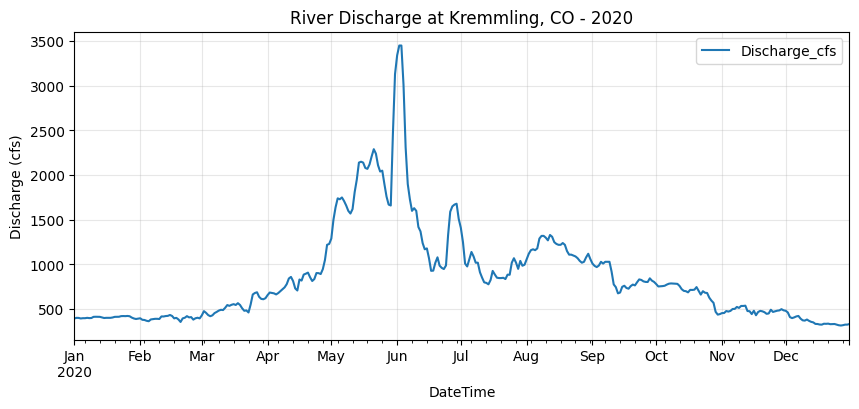

In [46]:
# making dataframe with only 2020 values
df_2020 = df[df['Year'] == 2020]

# create a basic line plot
df_2020.plot(x = 'DateTime', y='Discharge_cfs', 
             title = 'River Discharge at Kremmling, CO - 2020',
             figsize = (10,4))
plt.ylabel('Discharge (cfs)')
plt.grid(True, alpha=0.3)
plt.show()

## Method 2: Matplotlib Plotting
We can also just use our `matplotlib.pyplot` method for plotting, which allows for a LOT more customization.

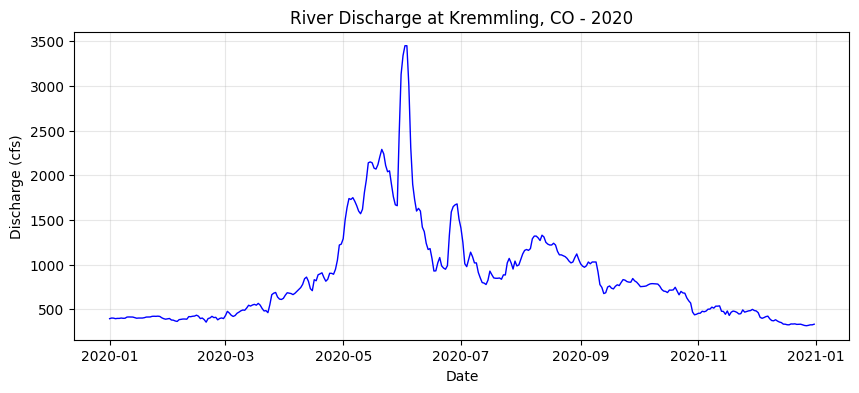

In [47]:
# Create the plot
plt.figure(figsize=(10, 4))
plt.plot(df_2020['DateTime'], df_2020['Discharge_cfs'], color='blue', linewidth=1)
plt.xlabel('Date')
plt.ylabel('Discharge (cfs)')
plt.title('River Discharge at Kremmling, CO - 2020')
plt.grid(True, alpha=0.3)
plt.show()

## Comparing Multiple Years
What if we wanted to plot multiple years on a single plot? It's a bit different than just plotting the data, because of how our x-axis is formatted.

If you just tried to plot them together, they'd be plotted end to end, which is great! but probably not what you wanted...

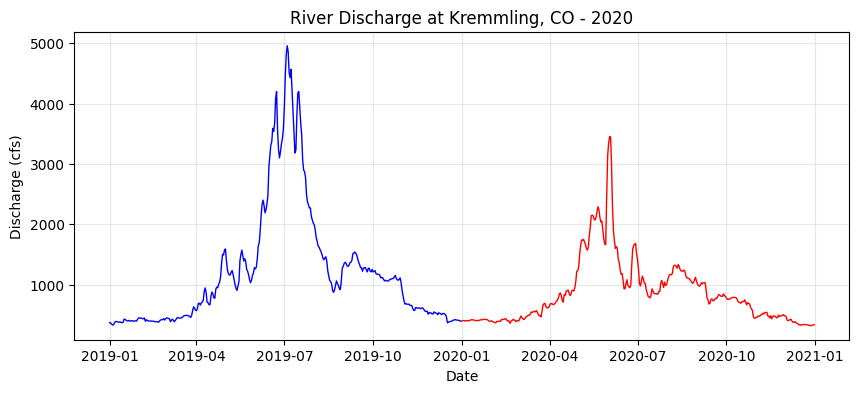

In [49]:
# Create the plot
df_2019 = df[df['Year'] == 2019]

plt.figure(figsize=(10, 4))
plt.plot(df_2019['DateTime'], df_2019['Discharge_cfs'], color='blue', linewidth=1)
plt.plot(df_2020['DateTime'], df_2020['Discharge_cfs'], color='red', linewidth=1)
plt.xlabel('Date')
plt.ylabel('Discharge (cfs)')
plt.title('River Discharge at Kremmling, CO - 2020')
plt.grid(True, alpha=0.3)
plt.show()

To plot them so the line up on the same x-axis, use the `DayOfYear` column as your x-axis data instead of `DateTime`:

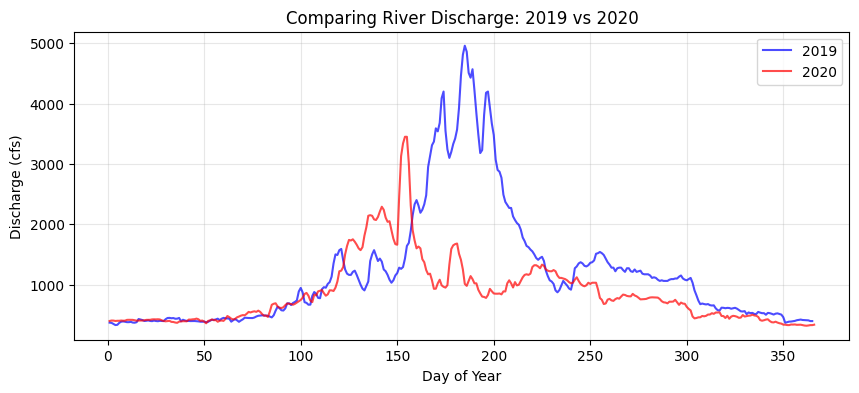

In [50]:
# Filter for 2019 and 2020
#df_2019 = df[df['Year'] == 2019]
#df_2020 = df[df['Year'] == 2020]

# Use day of year for x-axis so they line up
plt.figure(figsize=(10, 4))
plt.plot(df_2019['DayOfYear'], df_2019['Discharge_cfs'], label='2019', color='blue', alpha=0.7)
plt.plot(df_2020['DayOfYear'], df_2020['Discharge_cfs'], label='2020', color='red', alpha=0.7)
plt.xlabel('Day of Year')
plt.ylabel('Discharge (cfs)')
plt.title('Comparing River Discharge: 2019 vs 2020')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Scatter Plot
Sometimes scatter pltos are useful

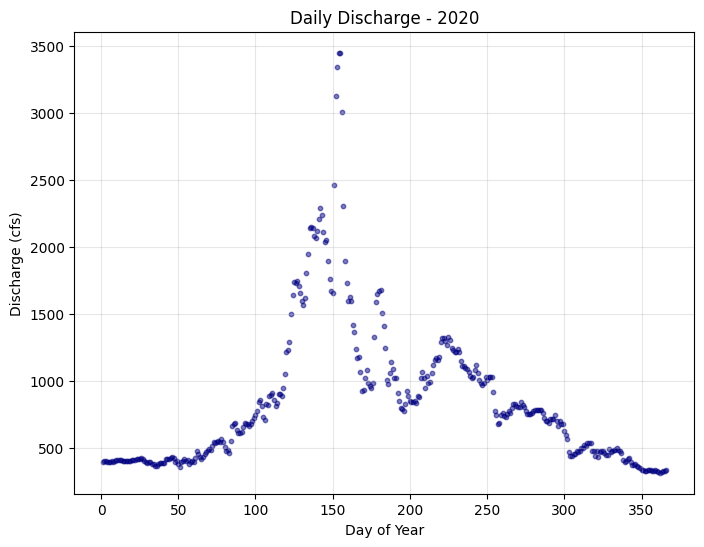

In [51]:
# Sometimes scatter plots are useful
plt.figure(figsize=(8, 6))
plt.scatter(df_2020['DayOfYear'], df_2020['Discharge_cfs'], alpha=0.5, s=10, color='navy')
plt.xlabel('Day of Year')
plt.ylabel('Discharge (cfs)')
plt.title('Daily Discharge - 2020')
plt.grid(True, alpha=0.3)
plt.show()

## Saving Figures
You can save figures just like you save any figure.

Remember you need to put `plt.savefig()` BEFORE `plt.show()`

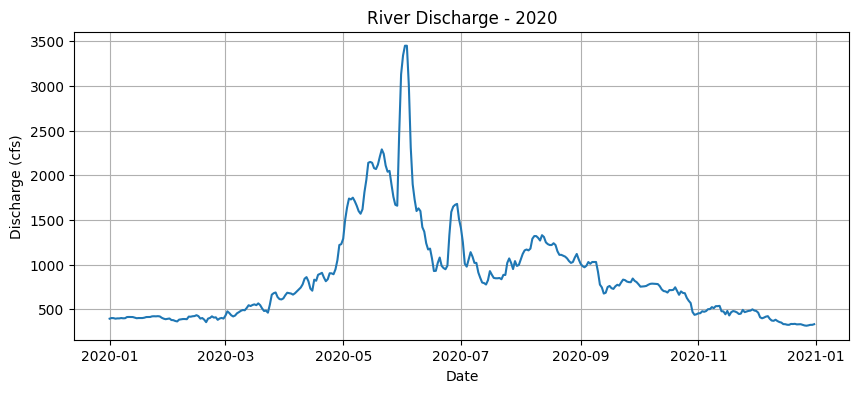

In [52]:
# Create a plot
plt.figure(figsize=(10, 4))
plt.plot(df_2020['DateTime'], df_2020['Discharge_cfs'])
plt.xlabel('Date')
plt.ylabel('Discharge (cfs)')
plt.title('River Discharge - 2020')
plt.grid(True)

# Save BEFORE plt.show()!
plt.savefig('discharge_2020.png', dpi=300, bbox_inches='tight')

plt.show()

# 11. Putting it all together!

Let's do a complete analysis in just a few lines:

Extreme flow events in 2020: 5
Max discharge: 3450 cfs
Mean during extreme events: 3276 cfs
High flow events in 2020: 14
Max discharge: 2460 cfs
Mean during high flow events: 2172 cfs


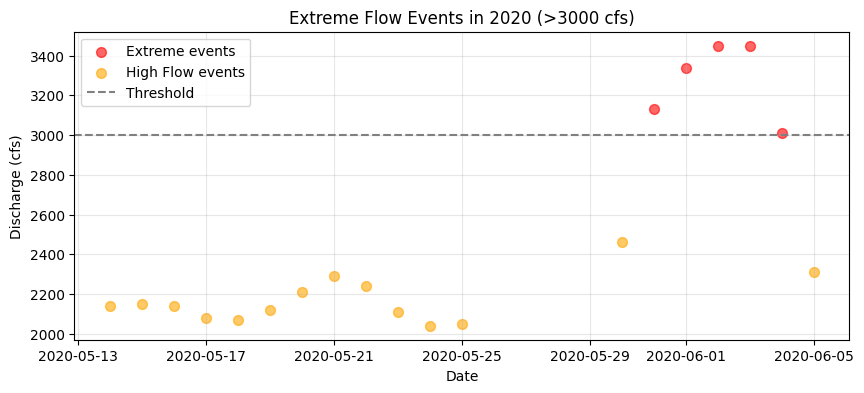

In [53]:
# Load and prepare data
df = pd.read_csv('USGS09058000_discharge_NoHead_20112021.csv')
df.columns = ['Agency', 'SiteNo', 'DateTime', 'Discharge_cfs']
df['DateTime'] = pd.to_datetime(df['DateTime'])
df['Year'] = df['DateTime'].dt.year

# Filter for extreme events in 2020
df_extreme = df[(df['Year'] == 2020) & (df['Discharge_cfs'] > 3000)]
df_high = df[(df['Year'] == 2020) & (df['Discharge_cfs'] > 2000) & (df['Discharge_cfs'] < 3000)]

# Print summary
print(f"Extreme flow events in 2020: {len(df_extreme)}")
print(f"Max discharge: {df_extreme['Discharge_cfs'].max():.0f} cfs")
print(f"Mean during extreme events: {df_extreme['Discharge_cfs'].mean():.0f} cfs")

print(f"High flow events in 2020: {len(df_high)}")
print(f"Max discharge: {df_high['Discharge_cfs'].max():.0f} cfs")
print(f"Mean during high flow events: {df_high['Discharge_cfs'].mean():.0f} cfs")


# Plot them
plt.figure(figsize=(10, 4))
plt.scatter(df_extreme['DateTime'], df_extreme['Discharge_cfs'], color='red', s=50, alpha=0.6, label='Extreme events')
plt.scatter(df_high['DateTime'], df_high['Discharge_cfs'], color='orange', s=50, alpha=0.6, label='High Flow events')
plt.axhline(y=3000, color='gray', linestyle='--', label='Threshold')
plt.xlabel('Date')
plt.ylabel('Discharge (cfs)')
plt.title('Extreme Flow Events in 2020 (>3000 cfs)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# What you've now learned throughout this whole notebook:
- load CSV data with `pd.read_csv()`
- explore data with `.head()`, `.info()`, `.dtypes`, `.shape`
- select columns with df['column'] or df[['col1', 'col2']]
- rename columns with `df.columns = new_list`
- add columns with calculations
- calculate statistics with `.mean()`, `.max()`, `.min()`, etc.
- convert strings to datetime with `pd.to_datetime()`
- extract date parts with `.dt.year`, `dt.month`, etc.
- use `iloc` for position-based indexing
- use `loc` for label-based indexing
- filter data with boolean indexing: df[df['column'] > value
- combine conditions with `&` and `|`
- create line plots with Pandas and matplotlib
- save figure with `plt.savefig()`